In [1]:
import nibabel as nib
import numpy as np
from nipype.interfaces import fsl

In [2]:
# Create a 3D array of zeros
shape = (182, 218, 182)  # Dimensions of MNI152 2mm space
data = np.zeros(shape)

# Create a NIfTI image
affine = np.array([
    [-2., 0., 0., 90.],
    [0., 2., 0., -126.],
    [0., 0., 2., -72.],
    [0., 0., 0., 1.]
])
img = nib.Nifti1Image(data, affine)

vmPFC coordinates based on Neubert et al. (2015)

In [4]:
# Convert MNI coordinates to voxel coordinates
vox_coords = np.array([-6, 32, -18])
vox_coords = nib.affines.apply_affine(np.linalg.inv(affine), vox_coords)
vox_coords = np.round(vox_coords).astype(int)

# Create a sphere
radius = 4  # You can adjust this
x, y, z = np.ogrid[-radius:radius+1, -radius:radius+1, -radius:radius+1]
sphere = x*x + y*y + z*z <= radius*radius

# Place the sphere in the image
x, y, z = vox_coords
data[x-radius:x+radius+1, y-radius:y+radius+1, z-radius:z+radius+1] = sphere

In [5]:
nib.save(img, 'vmPFC_mask.nii.gz')

In [7]:
# binarize the mask
fsl.maths.MathsCommand(
    in_file='vmPFC_mask.nii.gz',
    args='-bin',
    out_file='vmPFC_mask_bin.nii.gz'
).run()


In [8]:
import nibabel as nib
from nilearn import plotting
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
mask_img = nib.load('vmPFC_mask_bin.nii.gz')

In [12]:
# import nibabel as nib
# from nilearn import plotting
# import matplotlib.pyplot as plt

# # Load your mask
# mask_img = nib.load('vmPFC_mask_bin.nii.gz')

# # Create separate plots for each view
# plt.figure(figsize=(15, 5))

# # Sagittal view
# plt.subplot(131)
# plotting.plot_roi(mask_img, cut_coords=(-6, 0, 0), display_mode='x', title="Sagittal View")

# # Coronal view
# plt.subplot(132)
# plotting.plot_roi(mask_img, cut_coords=(0, 32, 0), display_mode='y', title="Coronal View")

# # Axial view
# plt.subplot(133)
# plotting.plot_roi(mask_img, cut_coords=(0, 0, -18), display_mode='z', title="Axial View")

# plt.tight_layout()
# plt.show()

# # 3D Glass Brain View
# plotting.plot_glass_brain(mask_img, title='3D Glass Brain View')
# plt.show()

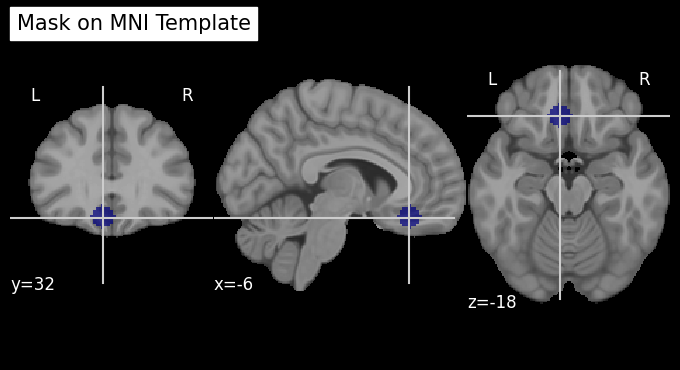

In [13]:
from nilearn.datasets import load_mni152_template

template = load_mni152_template()

plotting.plot_roi(mask_img, bg_img=template, cut_coords=(-6, 32, -18), title="Mask on MNI Template")
plt.show()